In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
def process_csv(filename):
    df = pd.read_csv(filename, index_col=0)
    df = df.sample(frac=1).reset_index(drop=True)
    df['vel_mag'] = np.sqrt(df['x_velocity_initial']**2 + df['y_velocity_initial']**2)
    df['driving_stress'] = df['h'] * 9.8 * df['mag_s']
    df['s/h'] = df['s'] / df['h']
    df['b/h'] = df['b'] / df['h']
    df['mag_s/mag_h'] = df['mag_s'] / df['mag_h']
    df['mag_b/mag_h'] = df['mag_b'] / df['mag_h']
    df['tu1'] = df['driving_stress'] / df['vel_mag']
    df['tu2'] = df['driving_stress'] / (df['vel_mag'] ** (1 / 2))
    df['tu3'] = df['driving_stress'] / (df['vel_mag'] ** (1 / 3))
    df['tu4'] = df['driving_stress'] / (df['vel_mag'] ** (1 / 4))
    df['tu5'] = df['driving_stress'] / (df['vel_mag'] ** (1 / 5))
    df['1/tu1'] = df['vel_mag'] / df['driving_stress']
    df['1/tu2'] = (df['vel_mag'] ** (1 / 2)) / df['driving_stress']
    df['1/tu3'] = (df['vel_mag'] ** (1 / 3)) / df['driving_stress']
    df['1/tu4'] = (df['vel_mag'] ** (1 / 4)) / df['driving_stress']
    df['1/tu5'] = (df['vel_mag'] ** (1 / 5)) / df['driving_stress']
    df['1/tu6'] = (df['vel_mag'] ** (1 / 6)) / df['driving_stress']
    df['invariant1_pow2'] = np.abs(df['invariant1']) ** (1 / 2)
    df['invariant1_pow3'] = np.abs(df['invariant1']) ** (1 / 3)
    df['invariant2_pow2'] = np.abs(df['invariant2']) ** (1 / 2)
    df['invariant2_pow3'] = np.abs(df['invariant2']) ** (1 / 3)
    #df['phi'] = df.apply(lambda row: get_phi(row['h'], row['s']), axis=1)
    #df['C_total'] = C0 * df['phi']*np.exp(df['C'])
    return df

In [6]:
df_pig = process_csv('regularized_const_01C_C_only_englacial_temp_pig_r005_geo_12.csv')

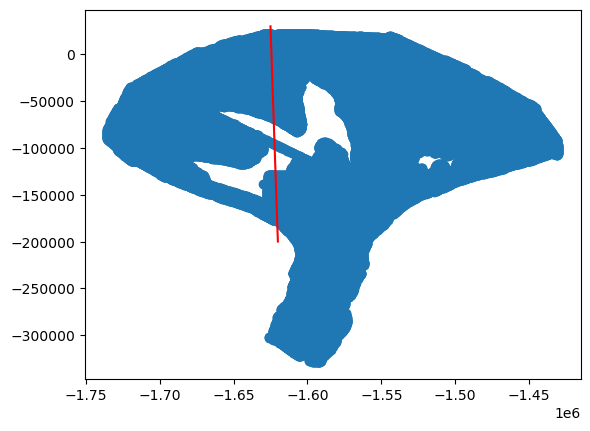

In [28]:
plt.scatter(df_pig['x'], df_pig['y'])
plt.plot([-1.62e6, -1.625e6], [-2e5, 30000], color='red')

In [43]:
# line coordinates
x_line = -1.625e6
y_min, y_max = -2e5, 30000

# condition for being in df_left
mask_left = (df_pig['x'] < x_line) & (df_pig['y'] >= y_min) & (df_pig['y'] <= y_max)

# split
df_left = df_pig[mask_left].copy()
df_right = df_pig[~mask_left].copy()

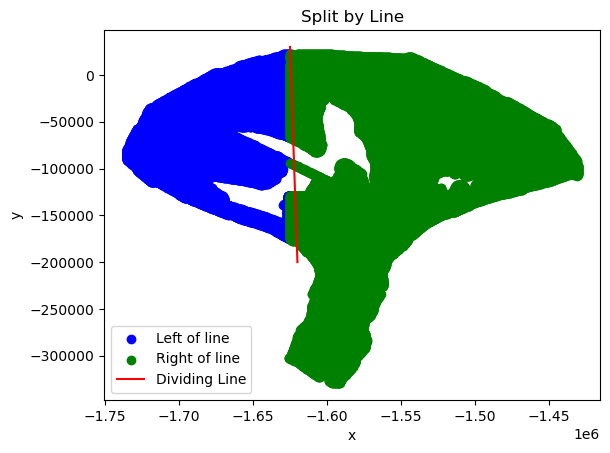

In [44]:
plt.scatter(df_left['x'], df_left['y'], color='blue', label='Left of line')
plt.scatter(df_right['x'], df_right['y'], color='green', label='Right of line')
plt.plot([-1.62e6, -1.625e6], [-2e5, 30000], color='red', label='Dividing Line')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Split by Line')
plt.show()